# Agreement analysis: Bland-Altman, MAE, MAPE

This notebook computes agreement statistics between a wearable (index measure) and a criterion (reference standard). We calculate Bland-Altman limits of agreement, mean absolute error (MAE), and mean absolute percentage error (MAPE). This can be used for VO2 max and energy expenditure, but not heart rate, which requires a different approach to account for repeated measures.

#### First, import necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import t
from scipy import stats
import plotly.express as px

## 1. Data exploration and processing

Write file path and read using ``pandas``

In [2]:
file_path = 'VO2max_EnergyExpenditure_data.csv'
df = pd.read_csv(file_path)

Explore data. We see below that test_date has dtype ``object``. We'll change this to dtype ``datetime``.

In [3]:
df.head()

,participant_id,test_date,vo2max_attained,cosmed_vo2max,pixel_vo2max,pixel_vo2max_estimate_date,include_vo2,cosmed_ee,pixel_ee
0,p01,13/2/25,Yes,46.41,48,13/2/25,y,197,251
1,p02,25/2/25,Yes,56.59,55,13/2/25,y,289,299
2,p03,25-02-2025,Yes,63.77,70,25/2/25,y,210,119
3,p04,11/3/25,No,no,-,-,n,-,-
4,p05,11/3/25,Yes,52.59,48,11/3/25,y,247,277


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   participant_id              34 non-null     object
 1   test_date                   34 non-null     object
 2   vo2max_attained             34 non-null     object
 3   cosmed_vo2max               34 non-null     object
 4   pixel_vo2max                34 non-null     object
 5   pixel_vo2max_estimate_date  34 non-null     object
 6   include_vo2                 34 non-null     object
 7   cosmed_ee                   34 non-null     object
 8   pixel_ee                    34 non-null     object
dtypes: object(9)
memory usage: 2.5+ KB


Convert to ``datetime``, using ``format='mixed'`` to account for the different date formats in our data. We also need ``dayfirst=True`` because by default it assumes dates are listed month first (but we use European-style dates). You can run ``help(pd.to_datetime)`` for more info.

In [5]:
df['test_date'] = pd.to_datetime(df['test_date'], format='mixed', dayfirst=True)

Confirm that our conversion worked

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   participant_id              34 non-null     object        
 1   test_date                   34 non-null     datetime64[ns]
 2   vo2max_attained             34 non-null     object        
 3   cosmed_vo2max               34 non-null     object        
 4   pixel_vo2max                34 non-null     object        
 5   pixel_vo2max_estimate_date  34 non-null     object        
 6   include_vo2                 34 non-null     object        
 7   cosmed_ee                   34 non-null     object        
 8   pixel_ee                    34 non-null     object        
dtypes: datetime64[ns](1), object(8)
memory usage: 2.5+ KB


### Data processing for VO2 max and energy expenditure

We'll need to drop participants who failed to attain true VO2 max during criterion testing. We'll also have to drop participants with missing VO2 max or energy expenditure values for either the criterion or index measure. Let's first look at how many participants we can expect to drop out of our complete participant set (34 participants) for VO2 max.

We can see below the number of participants that met inclusion criteria for VO2 max analysis.

In [7]:
df['include_vo2'].value_counts()

include_vo2
y    26
n     8
Name: count, dtype: int64

Let's convert the VO2 max and energy expenditure values to dtype ``numeric``, using ``errors='coerce'``, which inserts NaN for null values. These NaN values are the missing values that we will remove for analysis.

In [8]:
df['cosmed_vo2max'] = pd.to_numeric(df['cosmed_vo2max'], errors='coerce')
df['cosmed_ee'] = pd.to_numeric(df['cosmed_ee'], errors='coerce')
df['pixel_vo2max'] = pd.to_numeric(df['pixel_vo2max'], errors='coerce')
df['pixel_ee'] = pd.to_numeric(df['pixel_ee'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   participant_id              34 non-null     object        
 1   test_date                   34 non-null     datetime64[ns]
 2   vo2max_attained             34 non-null     object        
 3   cosmed_vo2max               33 non-null     float64       
 4   pixel_vo2max                26 non-null     float64       
 5   pixel_vo2max_estimate_date  34 non-null     object        
 6   include_vo2                 34 non-null     object        
 7   cosmed_ee                   33 non-null     float64       
 8   pixel_ee                    30 non-null     float64       
dtypes: datetime64[ns](1), float64(4), object(4)
memory usage: 2.5+ KB


#### Drop NaN values 

In [9]:
# change to cosmed_vo2max / pixel_vo2max as needed
df = df.dropna(subset=['pixel_ee', 'cosmed_ee'])

#### Drop participants who didn't attain VO2max

In [10]:
# df = df.loc[df['include_vo2'] == 'y']

### Define criterion and index measures

Now it's time to specify the criterion and index measures. This part can be reproducible across different devices, whereas cleaning and preprocessing typically requires you to adapt to your given data. 

Here, we'll do energy expenditure analysis, but this can be swapped out easily for VO2 max analysis.

In [11]:
# change to cosmed_vo2max / pixel_vo2max as needed
criterion = df['cosmed_ee'] # df['cosmed_ee'] or df['cosmed_vo2max']
index = df['pixel_ee'] # pixel_vo2max or pixel_ee

Define unit for plot

In [12]:
# unit = 'mL/kg/min'
# metric = 'VO$_2$ max'
unit = 'kcal'
metric = 'energy expenditure'

## 2. Bland-Altman limits of agreement analysis & plot

In [13]:
mean_diff_values = (criterion + index) / 2 # this is just for the BA plot
diff = index - criterion # important to note than mean diff is normally calculated as index measure - criterion for Bland-Altman
mean_diff = diff.mean()
std_diff = diff.std()

Calculate standard error

In [14]:
n = len(diff)
se_diff = std_diff / np.sqrt(n)

Calculate limits of agreement

In [15]:
loa_upper = mean_diff + 1.96 * std_diff
loa_lower = mean_diff - 1.96 * std_diff

Calculate 95% CI for the mean difference

In [16]:
ci_upper = mean_diff + 1.96 * se_diff
ci_lower = mean_diff - 1.96 * se_diff

Calculate mean and standard deviation for criterion and index

In [17]:
mean_criterion = criterion.mean()
criterion_std = criterion.std()
mean_index = index.mean()
index_std = index.std()

Calculate standard error for criterion and index

In [18]:
se_criterion = criterion_std / np.sqrt(n)
se_index = index_std / np.sqrt(n)

Calculate 95% CI for the upper and lower limits of agreement

In [19]:
## First calculate standard error of the loa
se_loa = std_diff * (np.sqrt((1/n) + ((1.96 ** 2) / (2 * (n - 1)))))
print(f"SE LoA: {se_loa:.4f}")

## Then calculate 95% CI
ci_lowerbound_upper_loa = loa_upper - 1.96 * se_loa
ci_upperbound_upper_loa = loa_upper + 1.96 * se_loa
ci_lowerbound_lower_loa = loa_lower - 1.96 * se_loa
ci_upperbound_lower_loa = loa_lower + 1.96 * se_loa

print(f"95% CI of lower LoA: ({ci_lowerbound_lower_loa:.4f}, {ci_upperbound_lower_loa:.4f})")
print(f"95% CI of upper LoA: ({ci_lowerbound_upper_loa:.4f}, {ci_upperbound_upper_loa:.4f})")

SE LoA: 10.3545
95% CI of lower LoA: (-93.0450, -52.4554)
95% CI of upper LoA: (35.5887, 76.1783)


Print results

In [20]:
print(f"The number of participants was: {len(diff)} \n--")
print(f"Mean Cosmed: {mean_criterion:.2f} {unit}.\nMean Pixel Watch: {mean_index:.2f} {unit}. \n--")
print(f"Cosmed standard deviation: {criterion_std:.2f}.\nPixel Watch standard deviation: {index_std:.2f} \n--")
print(f"Cosmed standard error: {se_criterion}.\nPixel Watch standard error: {se_index:.2f} \n--")
print(f'Standard deviation of mean difference (std of the difference): {std_diff:.2f}')
print(f'Standard error of mean difference: {se_diff:.2f}')
print(f'Mean difference: {mean_diff:.2f}')
print(f'95% CI of mean difference: [{ci_lower:.2f}, {ci_upper:.2f}]')
print(f'Upper limit of agreement: {loa_upper:.2f}')
print(f'Lower limit of agreement: {loa_lower:.2f}')
print(f"95% CI of limits of agreement for lower limit of agreement: {ci_lowerbound_lower_loa:.2f}, {ci_upperbound_lower_loa:.2f}")
print(f"95% CI of limits of agreement for upper limit of agreement: {ci_lowerbound_upper_loa:.2f}, {ci_upperbound_upper_loa:.2f}")

The number of participants was: 30 
--
Mean Cosmed: 173.07 kcal.
Mean Pixel Watch: 164.63 kcal. 
--
Cosmed standard deviation: 50.94.
Pixel Watch standard deviation: 53.78 
--
Cosmed standard error: 9.300714758509534.
Pixel Watch standard error: 9.82 
--
Standard deviation of mean difference (std of the difference): 32.81
Standard error of mean difference: 5.99
Mean difference: -8.43
95% CI of mean difference: [-20.18, 3.31]
Upper limit of agreement: 55.88
Lower limit of agreement: -72.75
95% CI of limits of agreement for lower limit of agreement: -93.04, -52.46
95% CI of limits of agreement for upper limit of agreement: 35.59, 76.18


#### Create Bland-Altman plot

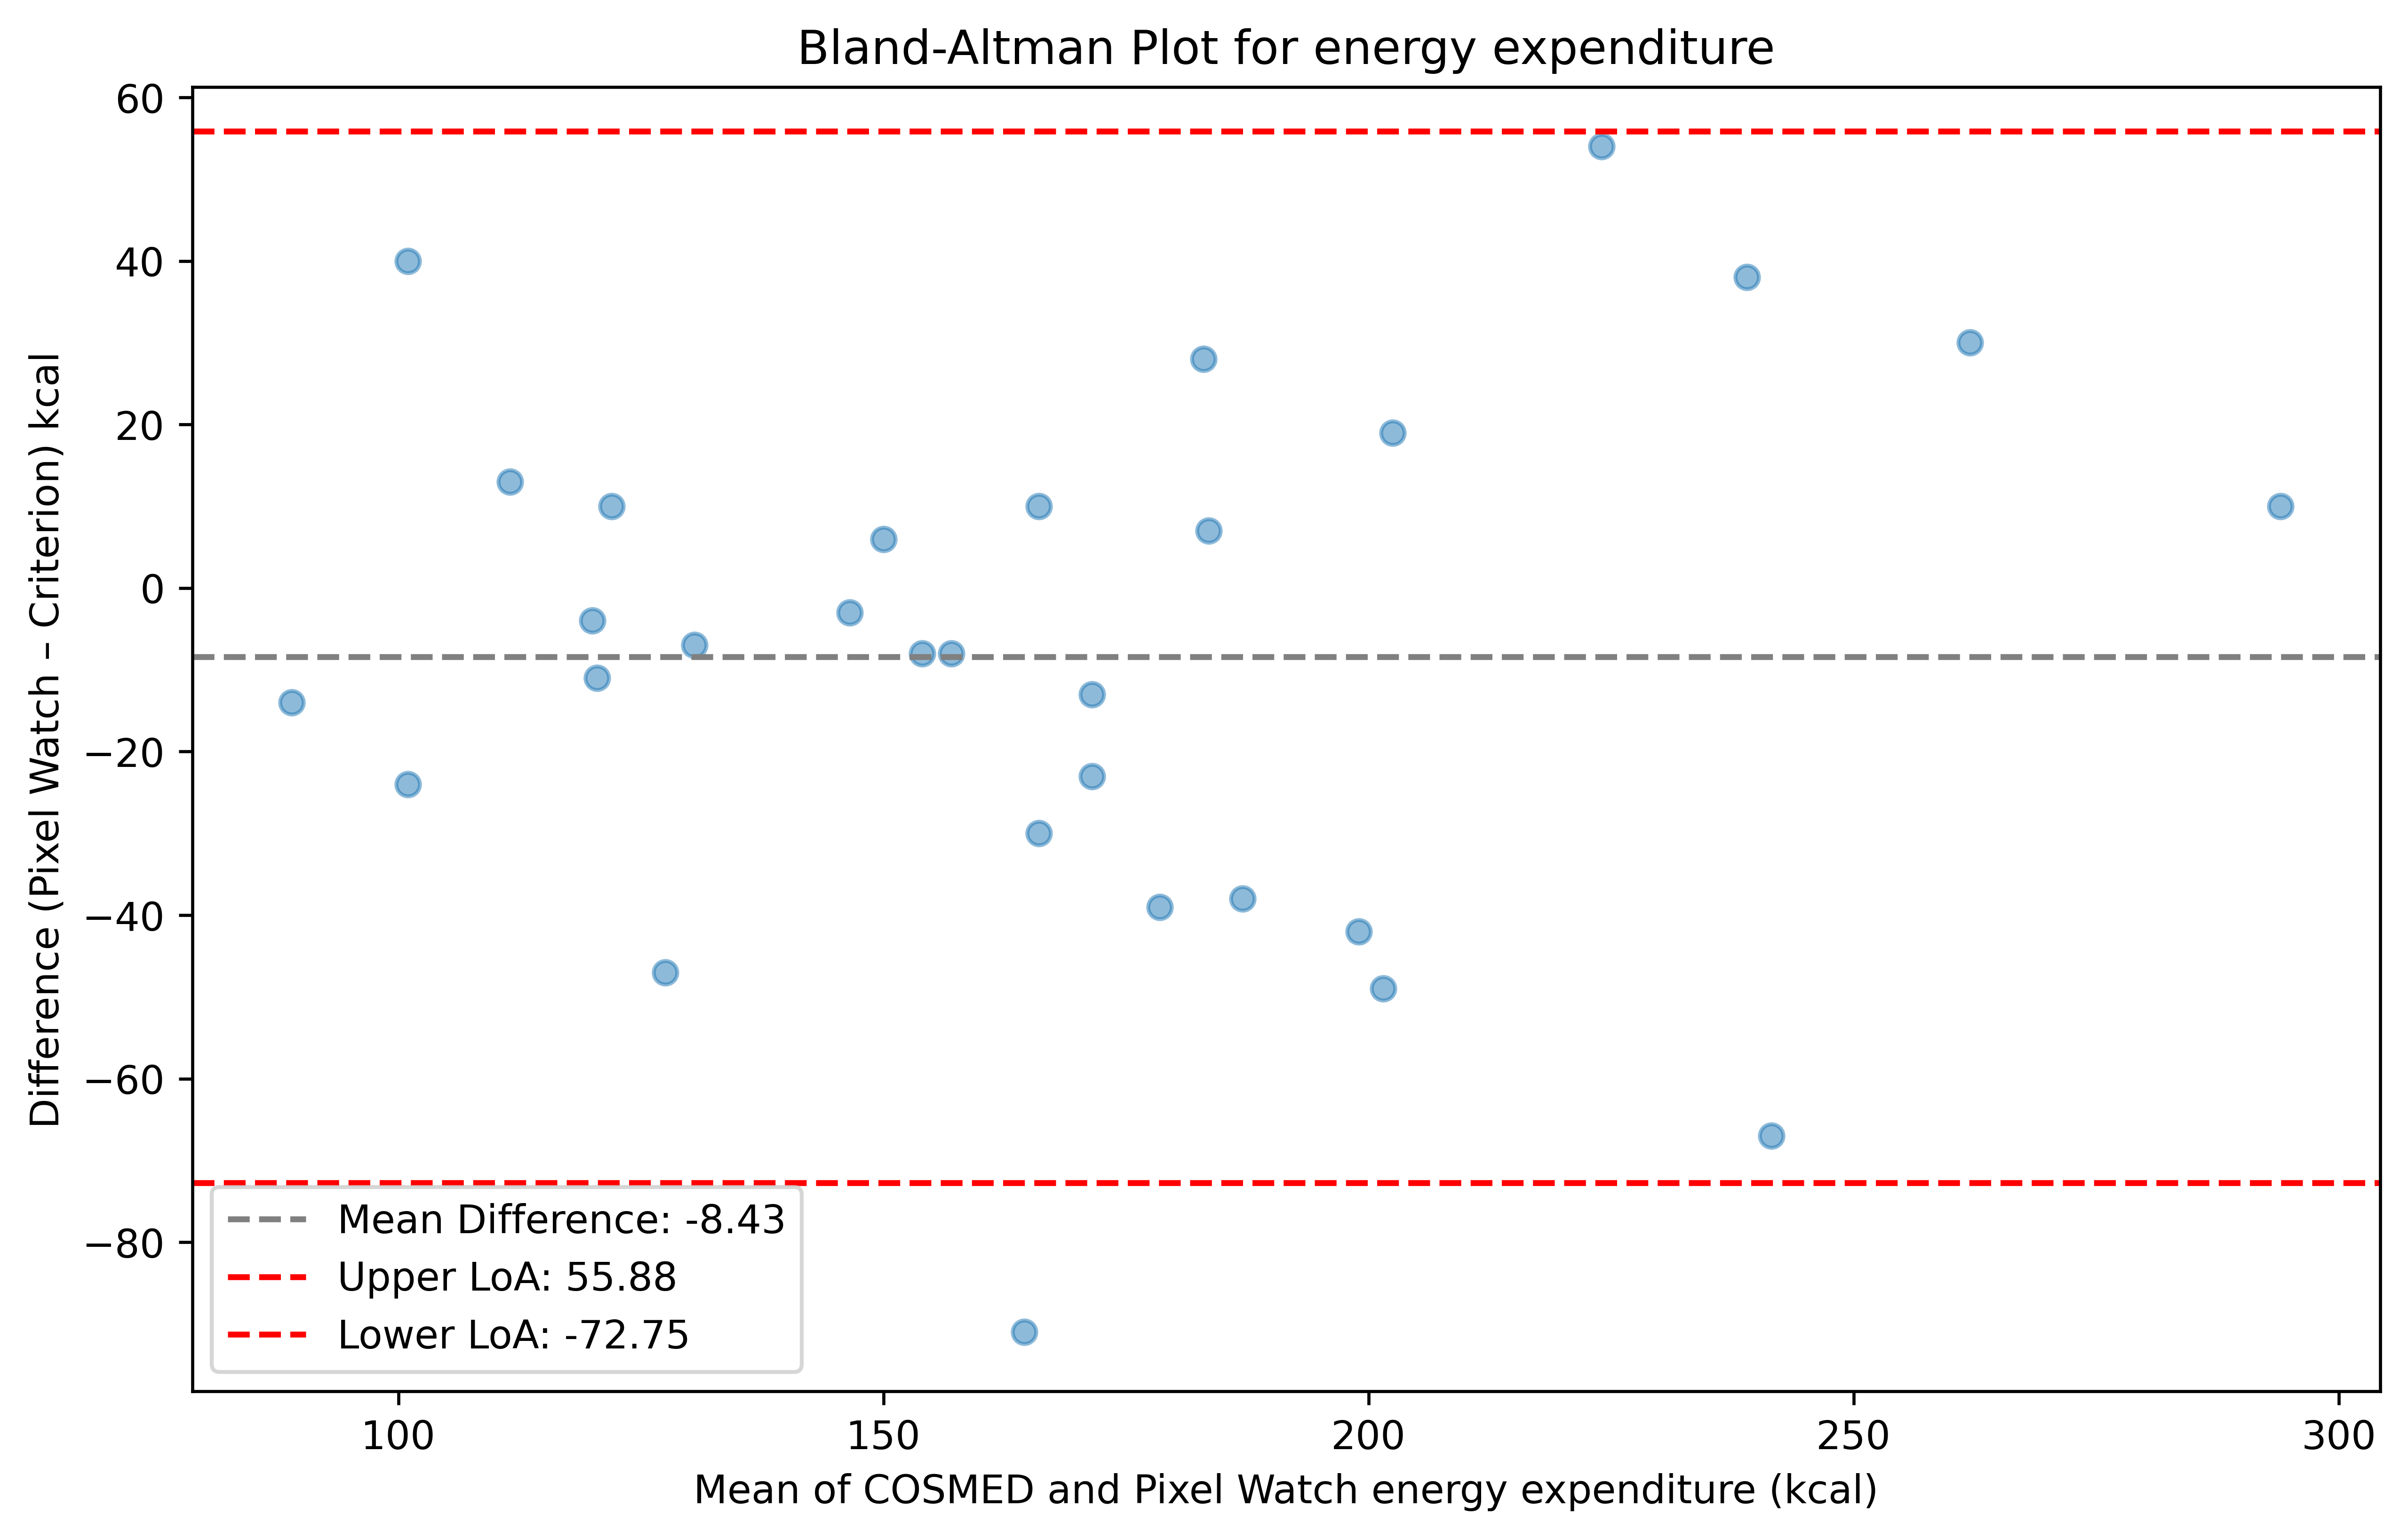

In [21]:
plt.rcParams['font.family'] = 'sans-serif'
plt.figure(figsize=(10, 6), dpi=600)
plt.scatter(mean_diff_values, diff, alpha=0.5)
plt.axhline(mean_diff, color='gray', linestyle='--', label=f'Mean Difference: {mean_diff:.2f}')
plt.axhline(loa_upper, color='red', linestyle='--', label=f'Upper LoA: {loa_upper:.2f}')
plt.axhline(loa_lower, color='red', linestyle='--', label=f'Lower LoA: {loa_lower:.2f}')
plt.title(f"Bland-Altman Plot for {metric}")
plt.xlabel(f"Mean of COSMED and Pixel Watch {metric} ({unit})") # VO$_2$ max or energy expenditure
plt.ylabel(f"Difference (Pixel Watch – Criterion) {unit}")
plt.legend()
# plt.savefig("pixel_blandAlt_plot_EE", dpi=1200)
plt.show()

## 3. Mean absolute percentage error (MAPE)

### MAPE function

Here is a handy function to calculate MAPE in a few lines of code. Below, the manual MAPE calculation preserves the underlying statistical steps.

In [22]:
def calculate_mape(criterion, index):
    criterion, index = np.array(criterion), np.array(index)
    return np.mean(np.abs((criterion - index) / criterion)) * 100

In [23]:
mape = calculate_mape(criterion, index)
print(f'MAPE: {mape:.4f} %')
print(f'Number of participants: {len(criterion)}')

MAPE: 15.0165 %
Number of participants: 30


#### Manual MAPE calculation

In [24]:
absolute_errors = (criterion - index).abs()

In [25]:
# Calculate absolute percentage errors
absolute_percentage_errors = (absolute_errors / criterion) * 100

In [26]:
# Sum the absolute percentage errors
sum_absolute_percentage_errors = absolute_percentage_errors.sum()

# Get the total number of data points
total_data_points = len(absolute_percentage_errors)

In [27]:
# Calculate MAPE
mape = sum_absolute_percentage_errors / total_data_points

In [28]:
# Calculate standard deviation and standard error for MAPE
std_percentage_error = absolute_percentage_errors.std()
n = len(absolute_percentage_errors)
se_percentage_error = std_percentage_error / np.sqrt(n)

We use t-critical values to calculate the 95% confidence intervals as our sample size is small. Alternatively, in a bigger sample, you may use the z-score approach.

In [29]:
# Calculate the t critical value for a 95% confidence level
t_critical = t.ppf(0.975, df=n-1)  # 0.975 corresponds to 95% two-tailed

# Calculate 95% CI for the MAPE
# ci_upper = mean_diff + 1.96 * se_diff_mae
# ci_lower = mean_diff - 1.96 * se_diff_mae

ci_upper = mape + (t_critical * se_percentage_error)
ci_lower = mape - (t_critical * se_percentage_error)

In [30]:
print(f"MAPE for {metric} is: {mape:.4f} %")
print(f"95% confidence intervals for the MAPE: {ci_lower:.2f}, {ci_upper:.2f}")
print(f"The standard error of the MAPE: {se_percentage_error:.2f}%")

MAPE for energy expenditure is: 15.0165 %
95% confidence intervals for the MAPE: 10.70, 19.33
The standard error of the MAPE: 2.11%


## 4. Mean absolute error

Just like MAPE, we can calculate mean absolute error using ``sklearn``, but the manual method below show how it works under the hood.

#### Manual MAE calculation

In [31]:
# Divide the sum by the total number of data points
mae = absolute_errors.mean()
print(mae)

26.1


#### MAE from sklearn

In [32]:
from sklearn.metrics import mean_absolute_error

y_true = criterion
y_pred = index
mae = mean_absolute_error(y_true, y_pred)

print(f'MAE from scikit-learn: {mae}')

MAE from scikit-learn: 26.1


##### 95% CI for MAE

In [33]:
# ** CALCULATE 95% CONFIDENCE INTERVAL **
# Calculate the standard deviation of the absolute errors
std_dev = absolute_errors.std(ddof=1)

# Calculate the standard error of the mean (SEM)
n = len(absolute_errors)
sem = std_dev / np.sqrt(n)

# Determine the t-critical value for a 95% confidence interval
confidence = 0.95
degrees_freedom = n - 1
alpha = 1 - confidence
t_crit = stats.t.ppf(1 - alpha/2, degrees_freedom)

# Calculate the margin of error
# Usually, margin of error = 1.96 * sem, but for smaller populations, t_crit is more appropriate
margin_of_error = t_crit * sem

# Compute the 95% confidence interval
lower_bound = mae - margin_of_error
upper_bound = mae + margin_of_error

In [34]:
print(f"The Mean Absolute Error for {metric} is {mae:.4f} {unit}.")
print(f"The 95% confidence interval is ({lower_bound:.4f}, {upper_bound:.4f}) {unit}.")
print(f"t-critical value: {t_crit:.4f}")
print(f"The standard error of the differences is {sem:.2f} {unit}")

The Mean Absolute Error for energy expenditure is 26.1000 kcal.
The 95% confidence interval is (18.2170, 33.9830) kcal.
t-critical value: 2.0452
The standard error of the differences is 3.85 kcal
